# Bilateral Filtering: Edge-Preserving Smoothing

Classical Gaussian blur smooths noise but also destroys edges.
Bilateral filtering adds a **range kernel** to avoid averaging across intensity jumps:
$$
\tilde f(i)=\frac{1}{Z_i}\sum_j
\exp\!\left(-\frac{\|i-j\|^2}{2\sigma_s^2}\right)
\exp\!\left(-\frac{(f(i)-f(j))^2}{2\sigma_r^2}\right) f(j).
$$

We explore the roles of spatial scale $\sigma_s$ and radiometric scale $\sigma_r$.


## Environment

A naive implementation is enough for pedagogical image sizes.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from ipywidgets import interact, FloatSlider

plt.rcParams["figure.dpi"] = 120
rng = np.random.default_rng(5)


## Noisy synthetic image

Construct a piecewise-smooth image with sharp edges and additive noise.


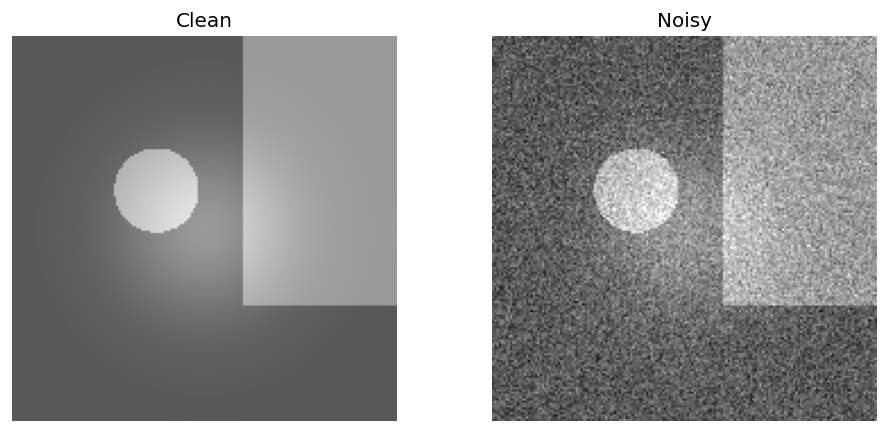

In [2]:
n = 170
y, x = np.mgrid[-1:1:complex(0, n), -1:1:complex(0, n)]
clean = 0.35 + 0.25 * np.exp(-5 * (x**2 + y**2))
clean += 0.3 * ((x + 0.25) ** 2 + (y - 0.2) ** 2 < 0.22**2)
clean += 0.25 * (x > 0.2) * (y > -0.4)
clean = np.clip(clean, 0, 1)
noisy = np.clip(clean + 0.09 * rng.standard_normal((n, n)), 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), constrained_layout=True)
axes[0].imshow(clean, cmap="gray", origin="lower", vmin=0, vmax=1)
axes[0].set_title("Clean")
axes[1].imshow(noisy, cmap="gray", origin="lower", vmin=0, vmax=1)
axes[1].set_title("Noisy")
for ax in axes:
    ax.axis("off")
plt.show()


## Bilateral filter implementation

Compute weighted local averages with spatial and range kernels.


In [3]:
def bilateral_filter(img, sigma_r=0.1, sigma_s=3.0):
    radius = int(np.ceil(3 * sigma_s))
    yy, xx = np.mgrid[-radius:radius+1, -radius:radius+1]
    spatial = np.exp(-(xx**2 + yy**2) / (2 * sigma_s**2))
    out = np.zeros_like(img)
    pad = np.pad(img, radius, mode="reflect")
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            patch = pad[i:i+2*radius+1, j:j+2*radius+1]
            range_w = np.exp(-((patch - img[i, j]) ** 2) / (2 * sigma_r**2))
            w = spatial * range_w
            out[i, j] = np.sum(w * patch) / np.sum(w)
    return out


## Interactive parameter study

Compare Gaussian blur and bilateral filtering under same settings.


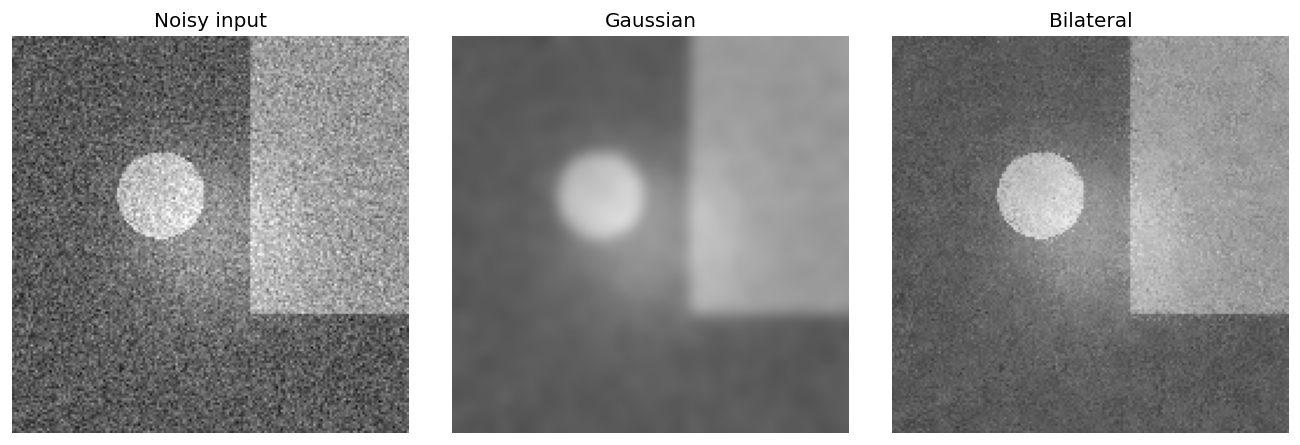

In [4]:
def compare_filters(sigma_s=3.0, sigma_r=0.12):
    gauss = gaussian_filter(noisy, sigma=sigma_s)
    bil = bilateral_filter(noisy, sigma_r=sigma_r, sigma_s=sigma_s)
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), constrained_layout=True)
    axes[0].imshow(noisy, cmap="gray", origin="lower", vmin=0, vmax=1)
    axes[0].set_title("Noisy input")
    axes[1].imshow(gauss, cmap="gray", origin="lower", vmin=0, vmax=1)
    axes[1].set_title("Gaussian")
    axes[2].imshow(bil, cmap="gray", origin="lower", vmin=0, vmax=1)
    axes[2].set_title("Bilateral")
    for ax in axes:
        ax.axis("off")
    plt.show()

# Static call for headless execution (keeps a representative bilateral-filter comparison).
compare_filters(sigma_s=3.0, sigma_r=0.12);


## Bibliographical resources

- Carlo Tomasi and Roberto Manduchi, *Bilateral Filtering for Gray and Color Images*, ICCV 1998.
- Sylvain Paris et al., *A Gentle Introduction to Bilateral Filtering and Its Applications*.
- Michael Elad, *Retinex by Two Bilateral Filters* (connections and variants).
